# Notebook 01 - SPARQL queries
This notebook is divided in **3 parts**:
1) **Metadata queries** - for understanding the content of the KG
2) **Structural validation queries** - for verifying the KG is semantically correct
3) **Property-specific measurement queries** - for understanding the data

## 0. Setup

In [78]:
!pip install sparqlwrapper pandas

In [88]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ENDPOINT = "http://34.68.13.168:7001"


def execute_query(query):
    sparql = SPARQLWrapper(ENDPOINT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    sparql.setMethod("POST")
    sparql.setTimeout(180)
    
    results = sparql.query().convert()
    vars_ = results["head"]["vars"]
    bindings = results["results"]["bindings"]
    
    data = []
    for row in bindings:
        entry = {}
        for var in vars_:
            entry[var] = row[var]["value"] if var in row else None
        data.append(entry)
    
    return pd.DataFrame(data)

try:
    test = execute_query("SELECT * WHERE {} LIMIT 1")
    print("Connection to QLever established:", ENDPOINT)
except:
    print("Connection to QLever failed.")
    

Connection to QLever established: http://34.68.13.168:7001


## 1. Metadata queries

### Knowledge Graph Statistics

In [89]:
queries_stats = {
    "Total triples":    "SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }",
    "Total sensors":    "PREFIX saref: <https://saref.etsi.org/core/> SELECT (COUNT(DISTINCT ?s) AS ?count) WHERE { ?s a saref:Sensor }",
    "Total BuildingSpaces":      "PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/> SELECT (COUNT(DISTINCT ?r) AS ?count) WHERE { ?r a s4bldg:BuildingSpace }",
    "Total FOIs":       "PREFIX saref: <https://saref.etsi.org/core/> SELECT (COUNT(DISTINCT ?f) AS ?count) WHERE { ?f a saref:FeatureOfInterest }",
    "Total properties": "PREFIX saref: <https://saref.etsi.org/core/> SELECT (COUNT(DISTINCT ?p) AS ?count) WHERE {{ ?p a saref:Property } UNION { ?p a saref:State } }",
    "Total measurements":     "PREFIX saref: <https://saref.etsi.org/core/> SELECT (COUNT(DISTINCT ?v) AS ?count) WHERE { ?v a saref:PropertyValue }",
}

for name, query in queries_stats.items():
    df = execute_query(query)
    print(f"{name}: {df['count'].iloc[0]}")

Total triples: 75476587
Total sensors: 51
Total BuildingSpaces: 22
Total FOIs: 19
Total properties: 780
Total measurements: 17443086


### Number of Sensors per floor

In [58]:
query_sensors_floor = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/>

SELECT ?floor (COUNT(DISTINCT ?sensor) AS ?count)
WHERE {
    ?sensor a saref:Sensor ;
            saref:isContainedIn ?room .
    ?room s4bldg:isSpaceOf ?floor .
}
GROUP BY ?floor
ORDER BY ?floor
"""

df_sensors_floor = execute_query(query_sensors_floor)
df_sensors_floor["floor"] = df_sensors_floor["floor"].str.split("#").str[-1]
print(df_sensors_floor)

      floor count
0  Floor_10     4
1  Floor_11    34
2  Floor_12    13


### Number of MCO sensors vs Thingy sensors per floor

In [4]:
for floor_num in [10, 11, 12]:
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (COUNT(DISTINCT ?sensor) AS ?count)
WHERE {{
    ?sensor a saref:Sensor ;
            saref:isContainedIn ?room .
    ?room s4bldg:isSpaceOf nu:Floor_{floor_num} .
    FILTER(CONTAINS(STR(?sensor), "mcomulti"))
}}
"""
    df_mco = execute_query(query)
    query2 = query.replace("mcomulti", "thingy")
    df_thingy = execute_query(query2)
    print(f"Floor {floor_num}: MCO={df_mco['count'].iloc[0]}, Thingy={df_thingy['count'].iloc[0]}")

Floor 10: MCO=0, Thingy=4
Floor 11: MCO=6, Thingy=28
Floor 12: MCO=0, Thingy=13


### Number of sensors per room

In [5]:
query_rooms = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/>

SELECT ?floor ?room (COUNT(DISTINCT ?sensor) AS ?sensor_count)
WHERE {
    ?sensor a saref:Sensor ;
            saref:isContainedIn ?room .
    ?room s4bldg:isSpaceOf ?floor .
}
GROUP BY ?floor ?room
ORDER BY ?floor ?room
"""

df_rooms = execute_query(query_rooms)
df_rooms["floor"] = df_rooms["floor"].str.split("#").str[-1]
df_rooms["room"] = df_rooms["room"].str.split("#").str[-1]
print(df_rooms.to_string(index=False))
print(f"\nTotal rooms: {len(df_rooms)}")
print(f"Total sensors: {df_rooms['sensor_count'].astype(int).sum()}")

   floor           room sensor_count
Floor_10 Room_NU-10A-01            2
Floor_10 Room_NU-10A-13            2
Floor_11 Room_NU-11A-29            3
Floor_11 Room_NU-11A-33            2
Floor_11 Room_NU-11A-37            3
Floor_11 Room_NU-11A-46            3
Floor_11 Room_NU-11A-48            3
Floor_11 Room_NU-11A-56            3
Floor_11 Room_NU-11A-58            3
Floor_11 Room_NU-11A-60            2
Floor_11 Room_NU-11A-65            9
Floor_11 Room_NU-11A-66            3
Floor_12 Room_NU-12A-48            1
Floor_12 Room_NU-12A-55            2
Floor_12 Room_NU-12A-56            2
Floor_12 Room_NU-12A-57            2
Floor_12 Room_NU-12A-58            2
Floor_12 Room_NU-12A-59            2
Floor_12 Room_NU-12A-60            2

Total rooms: 19
Total sensors: 51


### Dataset time range for Thingy and MCO sensors

In [8]:
for sensor_type in ["mcomulti", "thingy"]:
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (MIN(?timestamp) AS ?start) (MAX(?timestamp) AS ?end)
WHERE {{
    ?prop saref:isPropertyOf ?foi .
    ?prop saref:hasPropertyValue ?pv .
    ?pv saref:hasTimestamp ?timestamp .
    FILTER(CONTAINS(STR(?prop), "{sensor_type}"))
}}
"""
    df = execute_query(query)
    print(f"{sensor_type}: {df['start'].iloc[0]} → {df['end'].iloc[0]}")

mcomulti: 2022-12-23T00:00:00 → 2023-09-25T00:45:00
thingy: 2022-12-01T00:00:00 → 2023-10-09T15:30:00


## 2. Structural validation queries

### Building Hierarchy Validation

In [9]:
query_hierarchy = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT ?building ?floor ?room
WHERE {
    ?floor s4bldg:isSpaceOf ?building .
    ?room s4bldg:isSpaceOf ?floor .
    ?building a s4bldg:Building .
}
ORDER BY ?floor ?room
"""

df_hierarchy = execute_query(query_hierarchy)
df_hierarchy["building"] = df_hierarchy["building"].str.split("#").str[-1]
df_hierarchy["floor"] = df_hierarchy["floor"].str.split("#").str[-1]
df_hierarchy["room"] = df_hierarchy["room"].str.split("#").str[-1]
print(df_hierarchy.to_string(index=False))

   building    floor           room
NU_Building Floor_10 Room_NU-10A-01
NU_Building Floor_10 Room_NU-10A-13
NU_Building Floor_11 Room_NU-11A-29
NU_Building Floor_11 Room_NU-11A-33
NU_Building Floor_11 Room_NU-11A-37
NU_Building Floor_11 Room_NU-11A-46
NU_Building Floor_11 Room_NU-11A-48
NU_Building Floor_11 Room_NU-11A-56
NU_Building Floor_11 Room_NU-11A-58
NU_Building Floor_11 Room_NU-11A-60
NU_Building Floor_11 Room_NU-11A-65
NU_Building Floor_11 Room_NU-11A-66
NU_Building Floor_12 Room_NU-12A-48
NU_Building Floor_12 Room_NU-12A-55
NU_Building Floor_12 Room_NU-12A-56
NU_Building Floor_12 Room_NU-12A-57
NU_Building Floor_12 Room_NU-12A-58
NU_Building Floor_12 Room_NU-12A-59
NU_Building Floor_12 Room_NU-12A-60


### FeatureOfInterest-Room Validation

In [10]:
query_foi = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/>

SELECT ?room ?foi (COUNT(DISTINCT ?prop) AS ?properties)
WHERE {
    ?room saref:hasFeatureOfInterest ?foi .
    ?foi saref:hasProperty ?prop .
}
GROUP BY ?room ?foi
ORDER BY ?room
"""

df_foi = execute_query(query_foi)
df_foi["room"] = df_foi["room"].str.split("#").str[-1]
df_foi["foi"] = df_foi["foi"].str.split("#").str[-1]
df_foi["properties"] = df_foi["properties"].astype(int)
print(df_foi.to_string(index=False))
print(f"\nTotal FOIs: {len(df_foi)}")

          room                    foi  properties
Room_NU-10A-01 Room_NU-10A-01_Feature          32
Room_NU-10A-13 Room_NU-10A-13_Feature          32
Room_NU-11A-29 Room_NU-11A-29_Feature          48
Room_NU-11A-33 Room_NU-11A-33_Feature          32
Room_NU-11A-37 Room_NU-11A-37_Feature          42
Room_NU-11A-46 Room_NU-11A-46_Feature          42
Room_NU-11A-48 Room_NU-11A-48_Feature          42
Room_NU-11A-56 Room_NU-11A-56_Feature          42
Room_NU-11A-58 Room_NU-11A-58_Feature          42
Room_NU-11A-60 Room_NU-11A-60_Feature          32
Room_NU-11A-65 Room_NU-11A-65_Feature         144
Room_NU-11A-66 Room_NU-11A-66_Feature          42
Room_NU-12A-48 Room_NU-12A-48_Feature          16
Room_NU-12A-55 Room_NU-12A-55_Feature          32
Room_NU-12A-56 Room_NU-12A-56_Feature          32
Room_NU-12A-57 Room_NU-12A-57_Feature          32
Room_NU-12A-58 Room_NU-12A-58_Feature          32
Room_NU-12A-59 Room_NU-12A-59_Feature          32
Room_NU-12A-60 Room_NU-12A-60_Feature          32


### Sensor-Room Mapping Validation

In [76]:
query_sensor_rooms = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX s4bldg: <https://saref.etsi.org/saref4bldg/>

SELECT ?floor ?room ?sensor
WHERE {
    ?sensor a saref:Sensor ;
            saref:isContainedIn ?room .
    ?room s4bldg:isSpaceOf ?floor .
}
ORDER BY ?floor ?room ?sensor
"""

df_sensor_rooms = execute_query(query_sensor_rooms)
df_sensor_rooms["floor"] = df_sensor_rooms["floor"].str.split("#").str[-1]
df_sensor_rooms["room"] = df_sensor_rooms["room"].str.split("#").str[-1]
df_sensor_rooms["sensor"] = df_sensor_rooms["sensor"].str.split("#").str[-1]
print(df_sensor_rooms.to_string(index=False))

   floor           room             sensor
Floor_10 Room_NU-10A-01  thingy015_floor10
Floor_10 Room_NU-10A-01  thingy016_floor10
Floor_10 Room_NU-10A-13  thingy012_floor10
Floor_10 Room_NU-10A-13  thingy017_floor10
Floor_11 Room_NU-11A-29  thingy035_floor11
Floor_11 Room_NU-11A-29  thingy037_floor11
Floor_11 Room_NU-11A-29  thingy038_floor11
Floor_11 Room_NU-11A-33  thingy031_floor11
Floor_11 Room_NU-11A-33  thingy032_floor11
Floor_11 Room_NU-11A-37 mcomulti02_floor11
Floor_11 Room_NU-11A-37  thingy033_floor11
Floor_11 Room_NU-11A-37  thingy034_floor11
Floor_11 Room_NU-11A-46 mcomulti04_floor11
Floor_11 Room_NU-11A-46  thingy055_floor11
Floor_11 Room_NU-11A-46  thingy056_floor11
Floor_11 Room_NU-11A-48 mcomulti03_floor11
Floor_11 Room_NU-11A-48  thingy053_floor11
Floor_11 Room_NU-11A-48  thingy054_floor11
Floor_11 Room_NU-11A-56 mcomulti06_floor11
Floor_11 Room_NU-11A-56  thingy051_floor11
Floor_11 Room_NU-11A-56  thingy052_floor11
Floor_11 Room_NU-11A-58 mcomulti05_floor11
Floor_11 Ro

### Property Coverage per Sensor

In [19]:
query_coverage_of_properties = """
PREFIX saref: <https://saref.etsi.org/core/>

SELECT ?sensor (COUNT(DISTINCT ?prop) AS ?prop_count)
WHERE {
    ?sensor a saref:Sensor ;
            saref:observes ?prop .
}
GROUP BY ?sensor
ORDER BY ?sensor
"""

df_coverage_of_properties = execute_query(query_coverage_of_properties)
df_coverage_of_properties["sensor"] = df_coverage_of_properties["sensor"].str.split("#").str[-1]
df_coverage_of_properties["prop_count"] = df_coverage_of_properties["prop_count"].astype(int)
print(df_coverage_of_properties.to_string(index=False))

            sensor  prop_count
mcomulti01_floor11          10
mcomulti02_floor11          10
mcomulti03_floor11          10
mcomulti04_floor11          10
mcomulti05_floor11          10
mcomulti06_floor11          10
 thingy001_floor11          16
 thingy002_floor11          16
 thingy003_floor11          16
 thingy004_floor11          16
 thingy006_floor11          16
 thingy008_floor11          16
 thingy012_floor10          16
 thingy015_floor10          16
 thingy016_floor10          16
 thingy017_floor10          16
 thingy021_floor11          16
 thingy022_floor11          16
 thingy023_floor11          16
 thingy024_floor11          16
 thingy025_floor11          16
 thingy026_floor11          16
 thingy027_floor11          16
 thingy028_floor11          16
 thingy031_floor11          16
 thingy032_floor11          16
 thingy033_floor11          16
 thingy034_floor11          16
 thingy035_floor11          16
 thingy037_floor11          16
 thingy038_floor11          16
 thingy0

## 3. Property-specific measurement queries

### general_purpose (occupancy sensor) insights for all MCO sensors

In [72]:
mco_rooms = {
    "mcomulti01": "NU-11A-66",
    "mcomulti02": "NU-11A-37",
    "mcomulti03": "NU-11A-48",
    "mcomulti04": "NU-11A-46",
    "mcomulti05": "NU-11A-58",
    "mcomulti06": "NU-11A-56"
}

total_positive = 0
for sensor, room in mco_rooms.items():
    query_gp = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (COUNT(?val) AS ?total) 
WHERE {{
    nu:PresenceDetected_{sensor}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
    FILTER(?val = true)
}}
"""
    df = execute_query(query_gp)
    count = int(df["total"].iloc[0])
    total_positive += count
    print(f"{sensor} ({room}): {count} positive readings")

mcomulti01 (NU-11A-66): 2 positive readings
mcomulti02 (NU-11A-37): 2 positive readings
mcomulti03 (NU-11A-48): 1 positive readings
mcomulti04 (NU-11A-46): 0 positive readings
mcomulti05 (NU-11A-58): 2 positive readings
mcomulti06 (NU-11A-56): 5 positive readings


### Temperature insights per sensor

In [78]:
results_temp = []
missing_sensors = []

for _, row in df_sensor_rooms.iterrows():
    sensor = row["sensor"]
    
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MIN(?val) AS ?min) (MAX(?val) AS ?max) (COUNT(?val) AS ?count)
WHERE {{
    nu:Temperature_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
}}
"""
    df = execute_query(query)
    if df["avg"].iloc[0] is not None:
        results_temp.append({
            "sensor": sensor,
            "room": row["room"],
            "floor": row["floor"],
            "avg_temp": round(float(df["avg"].iloc[0]), 2),
            "min_temp": round(float(df["min"].iloc[0]), 2),
            "max_temp": round(float(df["max"].iloc[0]), 2),
            "count": int(df["count"].iloc[0])
        })
    else:
        missing_sensors.append({
            "sensor": sensor,
            "room": row["room"],
            "floor": row["floor"]
        })

df_temp = pd.DataFrame(results_temp)
print(df_temp.to_string(index=False))

print(f"\nSensors with no Temperature readings: {len(missing_sensors)}")
if missing_sensors:
    df_missing = pd.DataFrame(missing_sensors)
    print(df_missing.to_string(index=False))

            sensor           room    floor  avg_temp  min_temp  max_temp  count
 thingy015_floor10 Room_NU-10A-01 Floor_10     25.72     22.54     33.00  29803
 thingy016_floor10 Room_NU-10A-01 Floor_10     26.08     22.76     32.20  29380
 thingy012_floor10 Room_NU-10A-13 Floor_10     26.02     23.47     29.33   9935
 thingy017_floor10 Room_NU-10A-13 Floor_10     25.16     22.37     28.75   9429
 thingy035_floor11 Room_NU-11A-29 Floor_11      3.24      0.00     27.66  29680
 thingy037_floor11 Room_NU-11A-29 Floor_11      2.59      0.00     28.03  29691
 thingy038_floor11 Room_NU-11A-29 Floor_11     16.53      0.00     30.39  29632
 thingy031_floor11 Room_NU-11A-33 Floor_11     26.23     18.73     31.21  29629
 thingy032_floor11 Room_NU-11A-33 Floor_11     26.11     19.25     31.05  29633
mcomulti02_floor11 Room_NU-11A-37 Floor_11     21.62     14.54     25.28  22817
 thingy033_floor11 Room_NU-11A-37 Floor_11     25.57     16.55     29.32  26684
 thingy034_floor11 Room_NU-11A-37 Floor_

### Failed Sensors Validation Plots

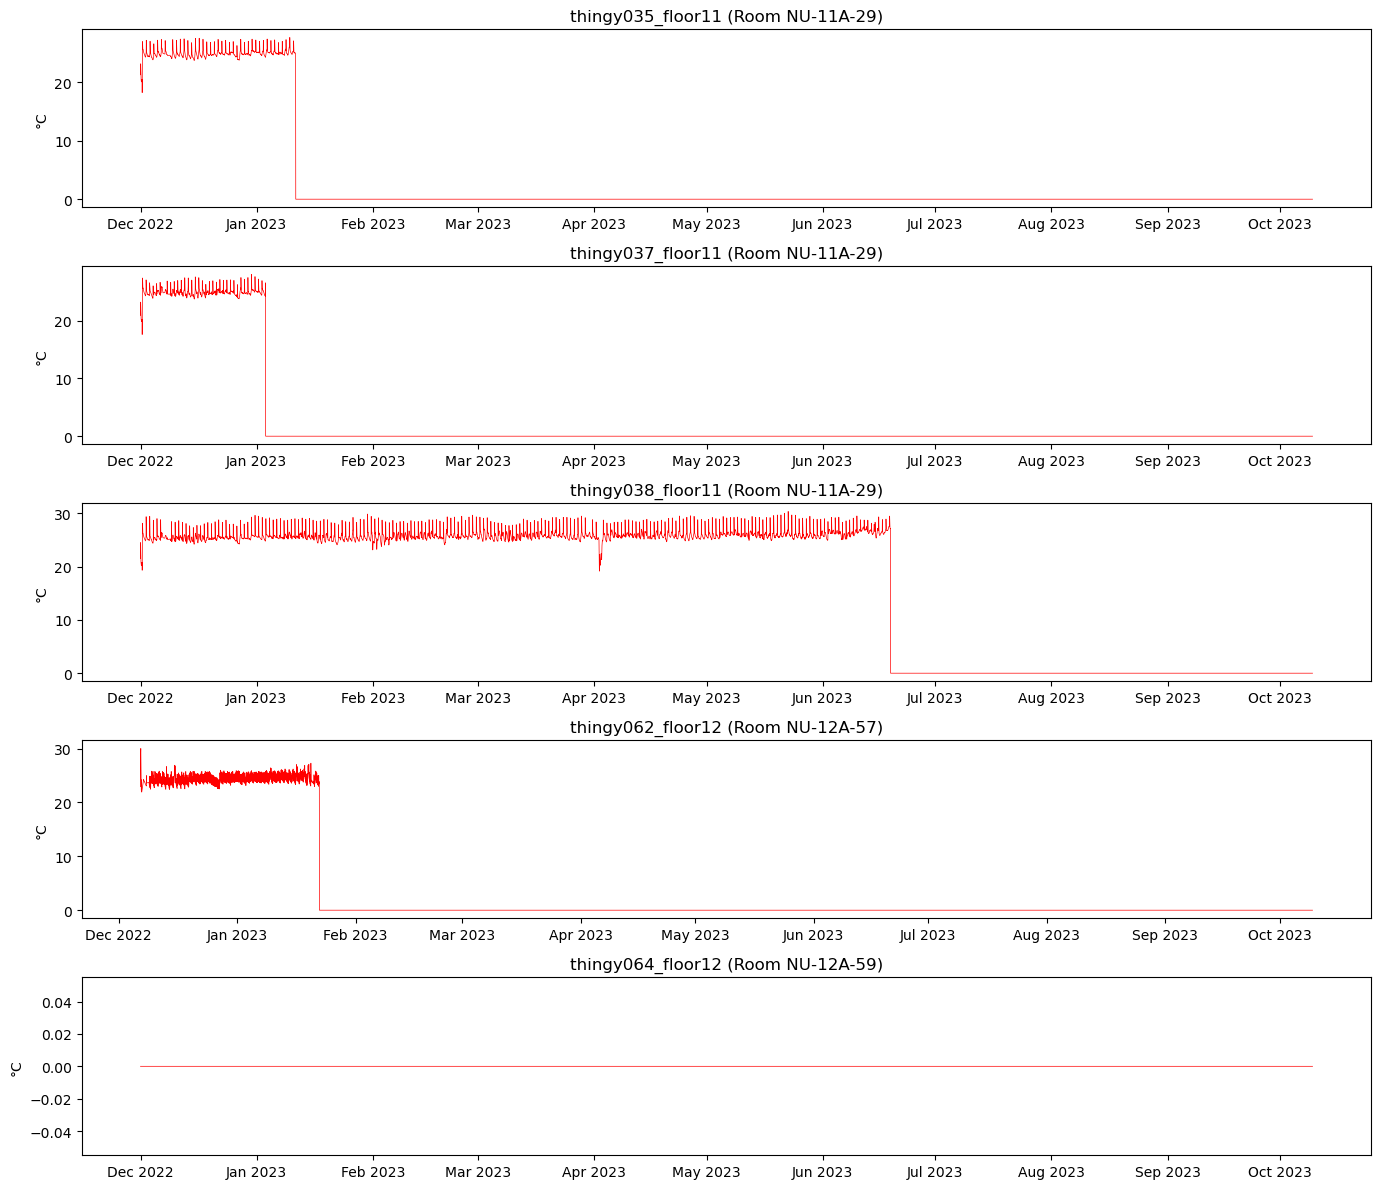

In [67]:
failed_sensors = {
    "thingy035_floor11": "NU-11A-29",
    "thingy037_floor11": "NU-11A-29", 
    "thingy038_floor11": "NU-11A-29",
    "thingy062_floor12": "NU-12A-57",
    "thingy064_floor12": "NU-12A-59"
}

fig, axes = plt.subplots(len(failed_sensors), 1, figsize=(14, 12))

for idx, (sensor, room) in enumerate(failed_sensors.items()):
    query_temp_failed = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT ?val ?timestamp
WHERE {{
    nu:Temperature_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
    df = execute_query(query_temp_failed)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["val"] = df["val"].astype(float)

    axes[idx].plot(df["timestamp"], df["val"], linewidth=0.5, color="red")
    axes[idx].set_title(f"{sensor} (Room {room})")
    axes[idx].set_ylabel("°C")
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

### Average Humidity per sensor

In [79]:
results_hum = []
missing_sensors = []

for _, row in df_sensor_rooms.iterrows():
    sensor = row["sensor"]
    
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:Humidity_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
}}
"""
    df = execute_query(query)
    if df["avg"].iloc[0] is not None:
        results_hum.append({
            "sensor": sensor,
            "room": row["room"],
            "floor": row["floor"],
            "avg_hum": round(float(df["avg"].iloc[0]), 2),
            "max_hum": round(float(df["max"].iloc[0]), 2),
        })
    else:
        missing_sensors.append({
            "sensor": sensor,
            "room": row["room"],
            "floor": row["floor"]
        })

df_hum = pd.DataFrame(results_hum)
print(df_hum.to_string(index=False))

print(f"\nSensors with no Humidity readings: {len(missing_sensors)}")
if missing_sensors:
    df_missing = pd.DataFrame(missing_sensors)
    print(df_missing.to_string(index=False))

            sensor           room    floor  avg_hum  max_hum
 thingy015_floor10 Room_NU-10A-01 Floor_10    43.72    74.74
 thingy016_floor10 Room_NU-10A-01 Floor_10    50.62    87.39
 thingy012_floor10 Room_NU-10A-13 Floor_10    40.51    58.83
 thingy017_floor10 Room_NU-10A-13 Floor_10    45.45    67.20
 thingy035_floor11 Room_NU-11A-29 Floor_11     4.50    58.04
 thingy037_floor11 Room_NU-11A-29 Floor_11     3.46    55.71
 thingy038_floor11 Room_NU-11A-29 Floor_11    22.96    56.00
 thingy031_floor11 Room_NU-11A-33 Floor_11    42.72    71.50
 thingy032_floor11 Room_NU-11A-33 Floor_11    41.92    71.33
mcomulti02_floor11 Room_NU-11A-37 Floor_11    46.64    78.80
 thingy033_floor11 Room_NU-11A-37 Floor_11    42.69    80.00
 thingy034_floor11 Room_NU-11A-37 Floor_11    42.42    77.00
mcomulti04_floor11 Room_NU-11A-46 Floor_11    42.05    69.00
 thingy055_floor11 Room_NU-11A-46 Floor_11    40.83    74.03
 thingy056_floor11 Room_NU-11A-46 Floor_11    41.34    72.29
mcomulti03_floor11 Room_

### Failed Sensors Validation Plots

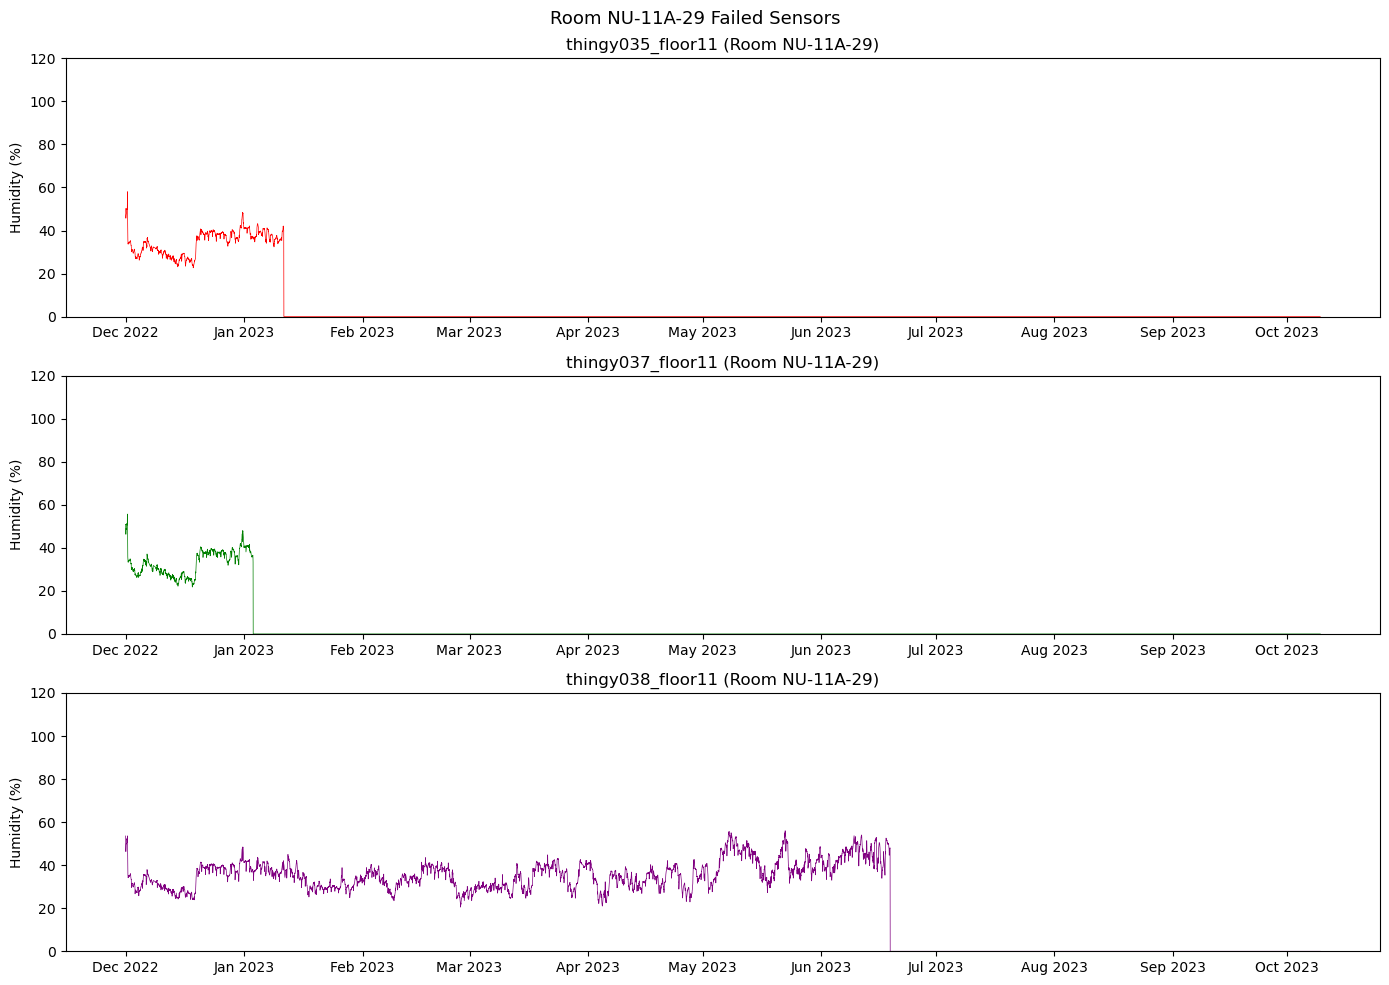

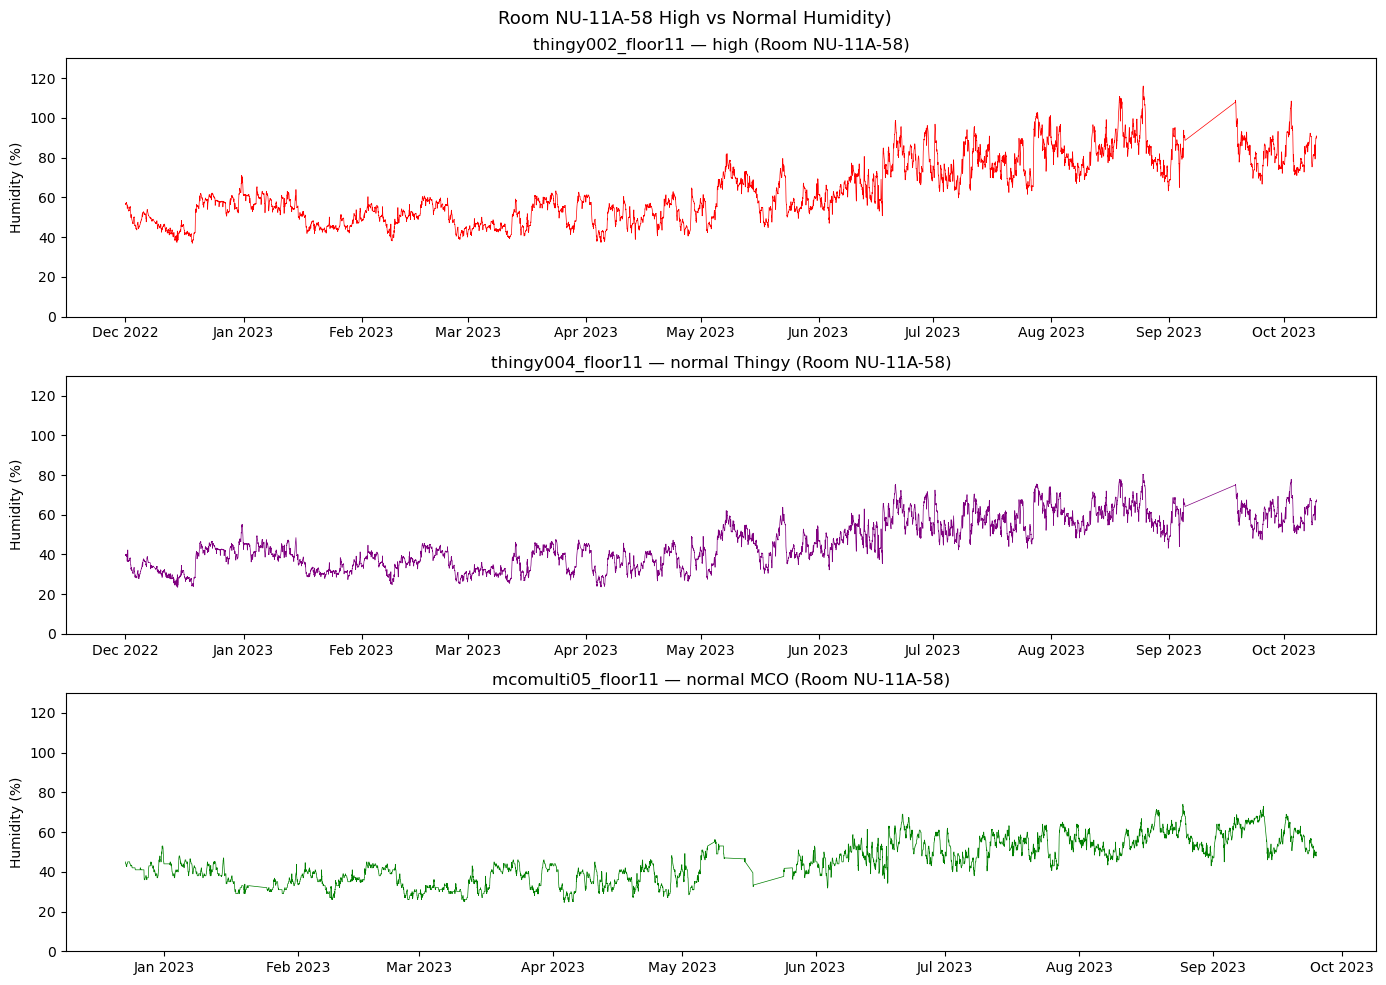

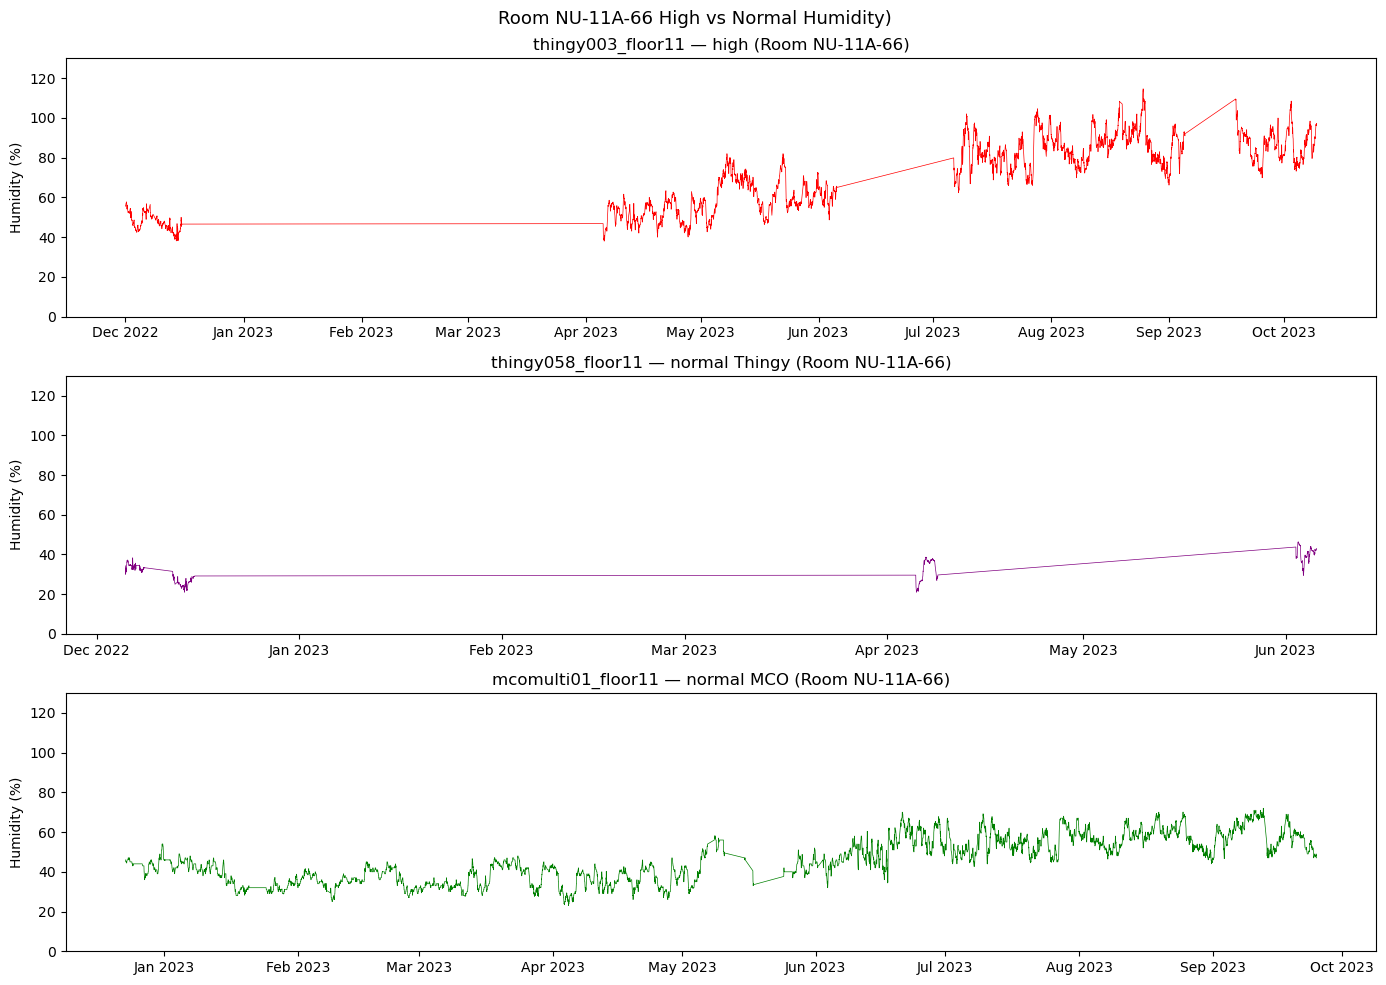

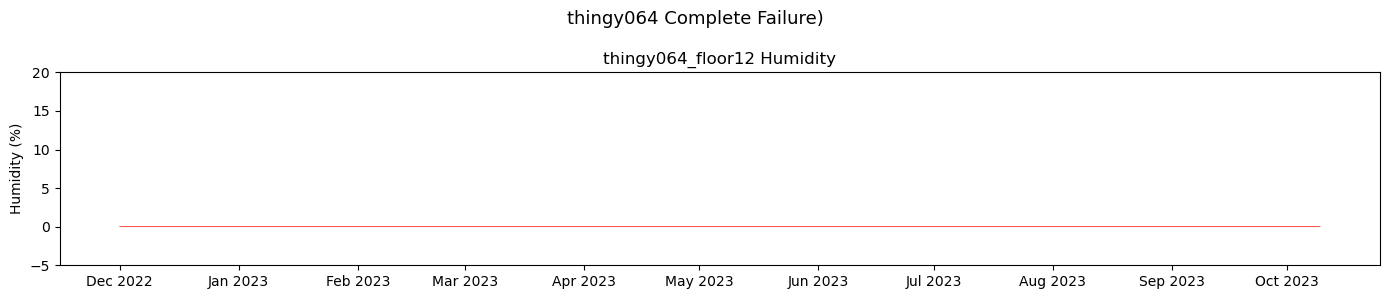

In [69]:
# Plot 1 (Room NU-11A-29 humidity comparison for sensors thingy035, thingy037, thingy038)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

room_29_sensors = {
    "thingy035_floor11": "red",
    "thingy037_floor11": "green", 
    "thingy038_floor11": "purple"
}

for idx, (sensor, color) in enumerate(room_29_sensors.items()):
    query_failed_hum_1 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:Humidity_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
    df = execute_query(query_failed_hum_1)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["val"] = df["val"].astype(float)
    axes[idx].plot(df["timestamp"], df["val"], linewidth=0.5, color=color)
    axes[idx].set_title(f"{sensor} (Room NU-11A-29)")
    axes[idx].set_ylabel("Humidity (%)")
    axes[idx].set_ylim(0, 120)
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.suptitle("Room NU-11A-29 Failed Sensors", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 2 (Room NU-11A-58 humidity comparison for sensors thingy002 and thingy004)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

room_58_sensors = {
    "thingy002_floor11": ("red", "high"),
    "thingy004_floor11": ("purple", "normal Thingy"),
    "mcomulti05_floor11": ("green", "normal MCO")
}

for idx, (sensor, (color, label)) in enumerate(room_58_sensors.items()):
    query_failed_hum_2 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:Humidity_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
    df = execute_query(query_failed_hum_2)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["val"] = df["val"].astype(float)
    axes[idx].plot(df["timestamp"], df["val"], linewidth=0.5, color=color)
    axes[idx].set_title(f"{sensor} — {label} (Room NU-11A-58)")
    axes[idx].set_ylabel("Humidity (%)")
    axes[idx].set_ylim(0, 130)
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.suptitle("Room NU-11A-58 High vs Normal Humidity)", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 3 (Room NU-11A-66 humidity comparison for sensors thingy003 and thingy058)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

room_66_sensors = {
    "thingy003_floor11": ("red", "high"),
    "thingy058_floor11": ("purple", "normal Thingy"),
    "mcomulti01_floor11": ("green", "normal MCO")
}

for idx, (sensor, (color, label)) in enumerate(room_66_sensors.items()):
    query_failed_hum_3 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:Humidity_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
    df = execute_query(query_failed_hum_3)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["val"] = df["val"].astype(float)
    axes[idx].plot(df["timestamp"], df["val"], linewidth=0.5, color=color)
    axes[idx].set_title(f"{sensor} — {label} (Room NU-11A-66)")
    axes[idx].set_ylabel("Humidity (%)")
    axes[idx].set_ylim(0, 130)
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.suptitle("Room NU-11A-66 High vs Normal Humidity)", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 4 (thingy064 humidity)
query_failed_hum_4 = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {
    nu:Humidity_thingy064_floor12 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}
ORDER BY ?timestamp
"""
df_064 = execute_query(query_failed_hum_4)
df_064["timestamp"] = pd.to_datetime(df_064["timestamp"])
df_064["val"] = df_064["val"].astype(float)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_064["timestamp"], df_064["val"], linewidth=0.5, color="red")
ax.set_title("thingy064_floor12 Humidity")
ax.set_ylabel("Humidity (%)")
ax.set_ylim(-5, 20)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.suptitle("thingy064 Complete Failure)", fontsize=13)
plt.tight_layout()
plt.show()

### CO2 meaurement comparison between MCO and Thingy sensors in Floor 11

In [80]:
# MCO
for i in range(1, 7):
    sensor = f"mcomulti0{i}_floor11"
    query_MCO_CO2 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (COUNT(?val) AS ?count) (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:eCO2_mcomulti0{i}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
    FILTER(?val > 0)
}}
"""
    df = execute_query(query_MCO_CO2)
    avg = round(float(df["avg"].iloc[0]), 1) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 1) if df["max"].iloc[0] else 0
    print(f"{sensor}: count={df['count'].iloc[0]}, avg={avg} ppm, max={max_} ppm")

# Thingy
for _, row in df_sensor_rooms[df_sensor_rooms["sensor"].str.contains("thingy")].iterrows():
    sensor = row["sensor"]

    query_Thingy_eCO2 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (COUNT(?val) AS ?count) (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:eCO2_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
    FILTER(?val > 0)
}}
"""
    df = execute_query(query_Thingy_eCO2)
    avg = round(float(df["avg"].iloc[0]), 1) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 1) if df["max"].iloc[0] else 0
    print(f"{sensor}: count={df['count'].iloc[0]}, avg={avg} ppm, max={max_} ppm")

mcomulti01_floor11: count=22797, avg=430.7 ppm, max=1095.1 ppm
mcomulti02_floor11: count=22816, avg=463.2 ppm, max=1885.7 ppm
mcomulti03_floor11: count=0, avg=0.0 ppm, max=0 ppm
mcomulti04_floor11: count=0, avg=0.0 ppm, max=0 ppm
mcomulti05_floor11: count=0, avg=0.0 ppm, max=0 ppm
mcomulti06_floor11: count=0, avg=0.0 ppm, max=0 ppm
thingy015_floor10: count=29803, avg=1019.6 ppm, max=6871.3 ppm
thingy016_floor10: count=29380, avg=1122.8 ppm, max=6656.8 ppm
thingy012_floor10: count=9935, avg=870.5 ppm, max=6900.0 ppm
thingy017_floor10: count=9429, avg=839.7 ppm, max=7133.4 ppm
thingy035_floor11: count=29680, avg=757.8 ppm, max=7265.6 ppm
thingy037_floor11: count=29691, avg=811.0 ppm, max=7083.4 ppm
thingy038_floor11: count=29632, avg=870.1 ppm, max=6818.6 ppm
thingy031_floor11: count=29629, avg=760.3 ppm, max=7413.0 ppm
thingy032_floor11: count=29633, avg=730.9 ppm, max=6811.2 ppm
thingy033_floor11: count=26684, avg=1201.5 ppm, max=7992.0 ppm
thingy034_floor11: count=26536, avg=980.8 ppm

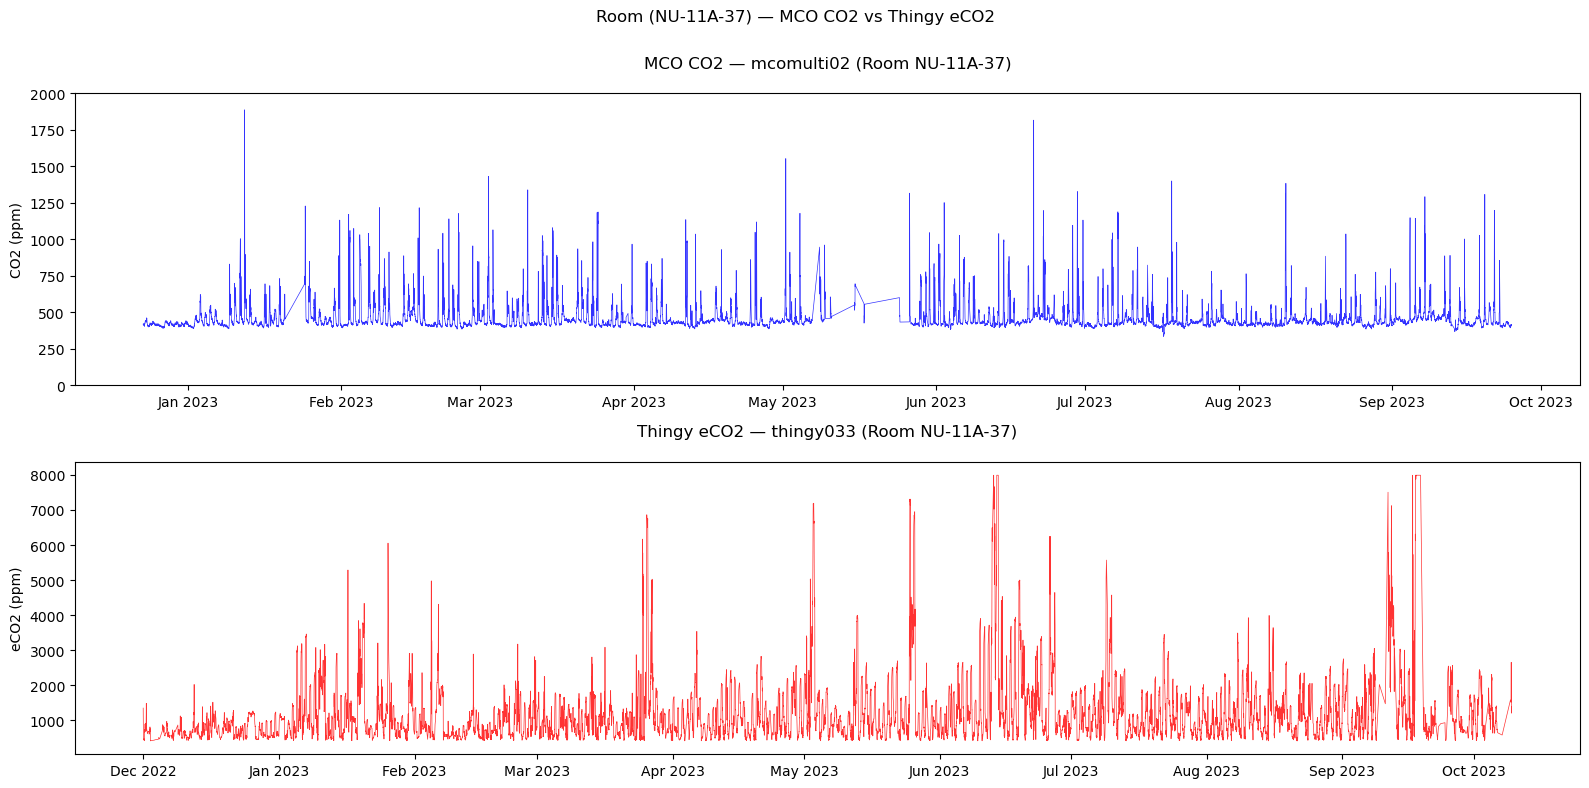

In [84]:
# thingy033 eCO2 time series
sensor = "thingy033_floor11"

query_thingy_eco2 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT ?val ?timestamp
WHERE {{
    nu:eCO2_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""

df_thingy_time = execute_query(query_thingy_eco2)
df_thingy_time["timestamp"] = pd.to_datetime(df_thingy_time["timestamp"])
df_thingy_time["val"] = df_thingy_time["val"].astype(float)

# mcomulti02 CO2 time series
query_mco = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {
    nu:eCO2_mcomulti02_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}
ORDER BY ?timestamp
"""
df_mco_time = execute_query(query_mco)
df_mco_time["timestamp"] = pd.to_datetime(df_mco_time["timestamp"])
df_mco_time["val"] = df_mco_time["val"].astype(float)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# MCO CO2 plot
axes[0].plot(df_mco_time["timestamp"], df_mco_time["val"],
             linewidth=0.5, color="blue", alpha=0.8)
axes[0].set_title("MCO CO2 — mcomulti02 (Room NU-11A-37)\n")
axes[0].set_ylabel("CO2 (ppm)")
axes[0].set_ylim(0, 2000)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Thingy eCO2 plot
axes[1].plot(df_thingy_time["timestamp"], df_thingy_time["val"],
             linewidth=0.5, color="red", alpha=0.8)
axes[1].set_title("Thingy eCO2 — thingy033 (Room NU-11A-37)\n")
axes[1].set_ylabel("eCO2 (ppm)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.suptitle("Room (NU-11A-37) — MCO CO2 vs Thingy eCO2\n", fontsize=12)
plt.tight_layout()
plt.show()

### TVOC and VOC Comparison

In [87]:
print("MCO VOC Level per sensor: ")
mco_rooms = {
    "mcomulti01": "NU-11A-66",
    "mcomulti02": "NU-11A-37",
    "mcomulti03": "NU-11A-48",
    "mcomulti04": "NU-11A-46",
    "mcomulti05": "NU-11A-58",
    "mcomulti06": "NU-11A-56",
}
for i in range(1, 7):
    query_voc = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max) (COUNT(?val) AS ?count)
WHERE {{
    nu:VOCLevel_mcomulti0{i}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
    FILTER(?val > 0)
}}
"""
    df = execute_query(query_voc)
    avg = round(float(df["avg"].iloc[0]), 2) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 2) if df["max"].iloc[0] else 0
    print(f"mcomulti0{i} ({mco_rooms[f'mcomulti0{i}']}): count={df['count'].iloc[0]}, avg={avg}, max={max_}")

print("\nThingy TVOC per sensor: ")
for _, row in df_sensor_rooms[df_sensor_rooms["sensor"].str.contains("thingy")].iterrows():
    sensor = row["sensor"]
    query_tvoc = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max) (COUNT(?val) AS ?count)
WHERE {{
    nu:TVOC_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
     FILTER(?val > 0)
}}
"""
    df = execute_query(query_tvoc)
    avg = round(float(df["avg"].iloc[0]), 2) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 2) if df["max"].iloc[0] else 0
    print(f"{sensor} ({row['room'].replace('Room_', '')}): count={df['count'].iloc[0]}, avg={avg}, max={max_}")

MCO VOC Level per sensor: 
mcomulti01 (NU-11A-66): count=16823, avg=3.89, max=29.21
mcomulti02 (NU-11A-37): count=17203, avg=1.95, max=29.21
mcomulti03 (NU-11A-48): count=22773, avg=0.98, max=32.52
mcomulti04 (NU-11A-46): count=18890, avg=0.56, max=13.04
mcomulti05 (NU-11A-58): count=22796, avg=0.73, max=12.21
mcomulti06 (NU-11A-56): count=22583, avg=1.02, max=32.39

Thingy TVOC per sensor: 
thingy015_floor10 (NU-10A-01): count=29803, avg=93.85, max=985.13
thingy016_floor10 (NU-10A-01): count=29380, avg=109.59, max=952.65
thingy012_floor10 (NU-10A-13): count=9935, avg=71.15, max=990.0
thingy017_floor10 (NU-10A-13): count=9429, avg=66.45, max=1025.29
thingy035_floor11 (NU-11A-29): count=29680, avg=53.96, max=1045.33
thingy037_floor11 (NU-11A-29): count=29691, avg=62.07, max=1017.74
thingy038_floor11 (NU-11A-29): count=29632, avg=71.07, max=977.38
thingy031_floor11 (NU-11A-33): count=29629, avg=54.36, max=1068.09
thingy032_floor11 (NU-11A-33): count=29633, avg=49.87, max=976.21
thingy033

### Illuminance (MCO) and color channels comparison (Thingy)

In [20]:
# MCO illuminance
for i in range(1, 7):
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:Illuminance_mcomulti0{i}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
}}
"""
    df = execute_query(query)
    avg = round(float(df["avg"].iloc[0]), 1) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 1) if df["max"].iloc[0] else 0
    print(f"mcomulti0{i}: avg={avg} lux, max={max_} lux")

# Thingy color channels
for _, row in df_sensor_rooms[df_sensor_rooms["sensor"].str.contains("thingy")].iterrows():
    sensor = row["sensor"]
    
    results_color = {}
    for channel in ["ColorR", "ColorG", "ColorB", "ColorC"]:
        query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:{channel}_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
}}
"""
        df = execute_query(query)
        avg = round(float(df["avg"].iloc[0]), 1) if df["avg"].iloc[0] else 0
        max_ = round(float(df["max"].iloc[0]), 1) if df["max"].iloc[0] else 0
        results_color[channel] = f"avg={avg}, max={max_}"
    
    print(f"{sensor} ({row['room'].replace('Room_', '')}):")
    for ch, vals in results_color.items():
        print(f"  {ch}: {vals} lux")

mcomulti01: avg=370.0 lux, max=5209.0 lux
mcomulti02: avg=946.2 lux, max=10844.3 lux
mcomulti03: avg=165.8 lux, max=1504.0 lux
mcomulti04: avg=408.9 lux, max=3475.7 lux
mcomulti05: avg=325.4 lux, max=3293.0 lux
mcomulti06: avg=435.5 lux, max=2818.0 lux
thingy015_floor10 (NU-10A-01):
  ColorR: avg=32.8, max=1969.5 lux
  ColorG: avg=67.2, max=6098.7 lux
  ColorB: avg=45.9, max=4207.7 lux
  ColorC: avg=7.0, max=626.8 lux
thingy016_floor10 (NU-10A-01):
  ColorR: avg=47.0, max=1500.0 lux
  ColorG: avg=91.9, max=4685.0 lux
  ColorB: avg=57.2, max=3366.5 lux
  ColorC: avg=9.0, max=433.3 lux
thingy012_floor10 (NU-10A-13):
  ColorR: avg=23.6, max=374.1 lux
  ColorG: avg=45.3, max=1070.4 lux
  ColorB: avg=25.8, max=699.6 lux
  ColorC: avg=4.6, max=104.1 lux
thingy017_floor10 (NU-10A-13):
  ColorR: avg=34.8, max=551.0 lux
  ColorG: avg=61.6, max=1346.5 lux
  ColorB: avg=36.0, max=1107.1 lux
  ColorC: avg=6.0, max=129.0 lux
thingy035_floor11 (NU-11A-29):
  ColorR: avg=28.2, max=264.8 lux
  ColorG:

### Loudness (MCO) comparison with sound (Thingy)

In [21]:
print("MCO Loudness per sensor: ")
for i in range(1, 7):
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:Loudness_mcomulti0{i}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
}}
"""
    df = execute_query(query)
    avg = round(float(df["avg"].iloc[0]), 1) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 1) if df["max"].iloc[0] else 0
    print(f"mcomulti0{i}: avg={avg} dB, max={max_} dB")

print("\n Thingy Sound per sensor: ")
for _, row in df_sensor_rooms[df_sensor_rooms["sensor"].str.contains("thingy")].iterrows():
    sensor = row["sensor"]
    
    query = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT (AVG(?val) AS ?avg) (MAX(?val) AS ?max)
WHERE {{
    nu:Sound_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val .
}}
"""
    df = execute_query(query)
    avg = round(float(df["avg"].iloc[0]), 1) if df["avg"].iloc[0] else 0
    max_ = round(float(df["max"].iloc[0]), 1) if df["max"].iloc[0] else 0
    print(f"{sensor} ({row['room'].replace('Room_', '')}): avg={avg}, max={max_} (raw amplitude)")

MCO Loudness per sensor: 
mcomulti01: avg=46.6 dB, max=87.3 dB
mcomulti02: avg=49.5 dB, max=97.0 dB
mcomulti03: avg=41.9 dB, max=85.0 dB
mcomulti04: avg=45.3 dB, max=97.0 dB
mcomulti05: avg=45.0 dB, max=83.0 dB
mcomulti06: avg=44.3 dB, max=79.0 dB

 Thingy Sound per sensor: 
thingy015_floor10 (NU-10A-01): avg=73.5, max=243.9 (raw amplitude)
thingy016_floor10 (NU-10A-01): avg=922.8, max=2174.0 (raw amplitude)
thingy012_floor10 (NU-10A-13): avg=84.9, max=824.0 (raw amplitude)
thingy017_floor10 (NU-10A-13): avg=70.7, max=231.7 (raw amplitude)
thingy035_floor11 (NU-11A-29): avg=76.2, max=670.0 (raw amplitude)
thingy037_floor11 (NU-11A-29): avg=59.3, max=496.4 (raw amplitude)
thingy038_floor11 (NU-11A-29): avg=855.1, max=1606.0 (raw amplitude)
thingy031_floor11 (NU-11A-33): avg=42.9, max=285.8 (raw amplitude)
thingy032_floor11 (NU-11A-33): avg=231.6, max=676.2 (raw amplitude)
thingy033_floor11 (NU-11A-37): avg=83.5, max=825.0 (raw amplitude)
thingy034_floor11 (NU-11A-37): avg=200.7, max=997